In [1]:
from google.colab import files
uploaded = files.upload()

Saving online_retail_II.xlsx to online_retail_II.xlsx


In [2]:
!pip install openpyxl -q

In [3]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

df = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2010-2011', engine='openpyxl')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (541910, 8)

Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

First 5 rows:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
# 2a. Basic cleaning
df.columns = df.columns.str.strip()
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Month'] = df['InvoiceDate'].dt.to_period('M')

# Remove cancelled orders (Invoice starts with 'C')
df_clean = df[~df['Invoice'].astype(str).str.startswith('C')].copy()

# Remove rows with no Customer ID (guest sessions — can't track behavior)
df_clean = df_clean.dropna(subset=['Customer ID'])
df_clean['Customer ID'] = df_clean['Customer ID'].astype(int)

# Remove bad prices and quantities
df_clean = df_clean[(df_clean['Price'] > 0) & (df_clean['Quantity'] > 0)]

# Add revenue column
df_clean['Revenue'] = df_clean['Price'] * df_clean['Quantity']

print("Cleaned shape:", df_clean.shape)
print("Cancelled orders removed:", df.shape[0] - df_clean.shape[0])
print("Unique customers:", df_clean['Customer ID'].nunique())
print("Date range:", df_clean['InvoiceDate'].min(), "→", df_clean['InvoiceDate'].max())

Cleaned shape: (397885, 10)
Cancelled orders removed: 144025
Unique customers: 4338
Date range: 2010-12-01 08:26:00 → 2011-12-09 12:50:00


In [5]:
#Step 3: Build the Funnel

# For each customer, compute funnel metrics
customer_stats = df_clean.groupby('Customer ID').agg(
    total_orders    = ('Invoice', 'nunique'),
    total_items     = ('Quantity', 'sum'),
    total_revenue   = ('Revenue', 'sum'),
    unique_products = ('StockCode', 'nunique'),
    active_months   = ('Month', 'nunique'),
    first_purchase  = ('InvoiceDate', 'min'),
    last_purchase   = ('InvoiceDate', 'max')
).reset_index()

# Stage 1 — Acquired:   any customer who made at least 1 purchase
# Stage 2 — Engaged:    bought more than 1 product type (explored the catalog)
# Stage 3 — Converted:  placed 3+ orders (committed buyer)
# Stage 4 — Retained:   active in 3+ months (loyal, came back repeatedly)

acquired  = customer_stats
engaged   = customer_stats[customer_stats['unique_products'] > 1]
converted = customer_stats[customer_stats['total_orders'] >= 3]
retained  = customer_stats[customer_stats['active_months'] >= 3]

funnel = pd.DataFrame({
    'Stage':      ['1. Acquired', '2. Engaged', '3. Converted', '4. Retained'],
    'Customers':  [len(acquired), len(engaged), len(converted), len(retained)],
})

funnel['Drop-off %'] = (
    (1 - funnel['Customers'] / funnel['Customers'].shift(1)) * 100
).round(1)
funnel['Drop-off %'] = funnel['Drop-off %'].fillna(0)
funnel['Conversion %'] = (funnel['Customers'] / len(acquired) * 100).round(1)

print(funnel.to_string(index=False))

       Stage  Customers  Drop-off %  Conversion %
 1. Acquired       4338         0.0         100.0
  2. Engaged       4247         2.1          97.9
3. Converted       2010        52.7          46.3
 4. Retained       1787        11.1          41.2


In [6]:
#Step 4: Segment the drop-off
import numpy as np

def assign_stage(row):
    if row['active_months'] >= 3:
        return '4. Retained'
    elif row['total_orders'] >= 3:
        return '3. Converted'
    elif row['unique_products'] > 1:
        return '2. Engaged'
    else:
        return '1. Acquired'

customer_stats['stage'] = customer_stats.apply(assign_stage, axis=1)

#Segment 1: by Country
country_map = df_clean.groupby('Customer ID')['Country'].first().reset_index()
customer_stats = customer_stats.merge(country_map, on='Customer ID')

country_funnel = customer_stats.groupby(['Country', 'stage']).size().unstack(fill_value=0)
country_funnel['total'] = country_funnel.sum(axis=1)
country_funnel = country_funnel[country_funnel['total'] >= 30]  # min 30 customers

if '2. Engaged' in country_funnel.columns and '3. Converted' in country_funnel.columns:
    country_funnel['engaged_not_converted'] = country_funnel.get('2. Engaged', 0)
    country_funnel['conversion_rate'] = (
        (country_funnel.get('3. Converted', 0) + country_funnel.get('4. Retained', 0))
        / country_funnel['total'] * 100
    ).round(1)

print("── Conversion rate by country ──")
print(country_funnel[['total', 'conversion_rate']].sort_values('conversion_rate').to_string())

#Segment 2: by Order Size
customer_stats['avg_order_value'] = (customer_stats['total_revenue'] / customer_stats['total_orders']).round(2)
customer_stats['aov_bucket'] = pd.cut(
    customer_stats['avg_order_value'],
    bins=[0, 50, 150, 500, 99999],
    labels=['Low (<£50)', 'Mid (£50-150)', 'High (£150-500)', 'VHigh (>£500)']
)

aov_funnel = customer_stats.groupby(['aov_bucket', 'stage']).size().unstack(fill_value=0)
aov_funnel['total'] = aov_funnel.sum(axis=1)
aov_funnel['conversion_rate'] = (
    (aov_funnel.get('3. Converted', 0) + aov_funnel.get('4. Retained', 0))
    / aov_funnel['total'] * 100
).round(1)

print("\n── Conversion rate by avg order value ──")
print(aov_funnel[['total', 'conversion_rate']].to_string())

#Segment 3: by Month of First Purchase
customer_stats['first_month'] = pd.to_datetime(
    customer_stats['first_purchase']
).dt.to_period('M')

cohort_funnel = customer_stats.groupby(['first_month', 'stage']).size().unstack(fill_value=0)
cohort_funnel['total'] = cohort_funnel.sum(axis=1)
cohort_funnel['conversion_rate'] = (
    (cohort_funnel.get('3. Converted', 0) + cohort_funnel.get('4. Retained', 0))
    / cohort_funnel['total'] * 100
).round(1)

print("\n── Conversion rate by acquisition month ──")
print(cohort_funnel[['total', 'conversion_rate']].to_string())

── Conversion rate by country ──
stage           total  conversion_rate
Country                               
United Kingdom   3920             46.5
France             87             52.9
Germany            94             53.2

── Conversion rate by avg order value ──
stage            total  conversion_rate
aov_bucket                             
Low (<£50)          59             22.0
Mid (£50-150)      683             29.0
High (£150-500)   2809             49.9
VHigh (>£500)      787             50.4

── Conversion rate by acquisition month ──
stage        total  conversion_rate
first_month                        
2010-12        885             74.7
2011-01        417             66.4
2011-02        380             58.4
2011-03        452             50.2
2011-04        300             47.3
2011-05        284             43.3
2011-06        242             40.5
2011-07        188             34.0
2011-08        169             26.6
2011-09        299             22.7
2011-10       

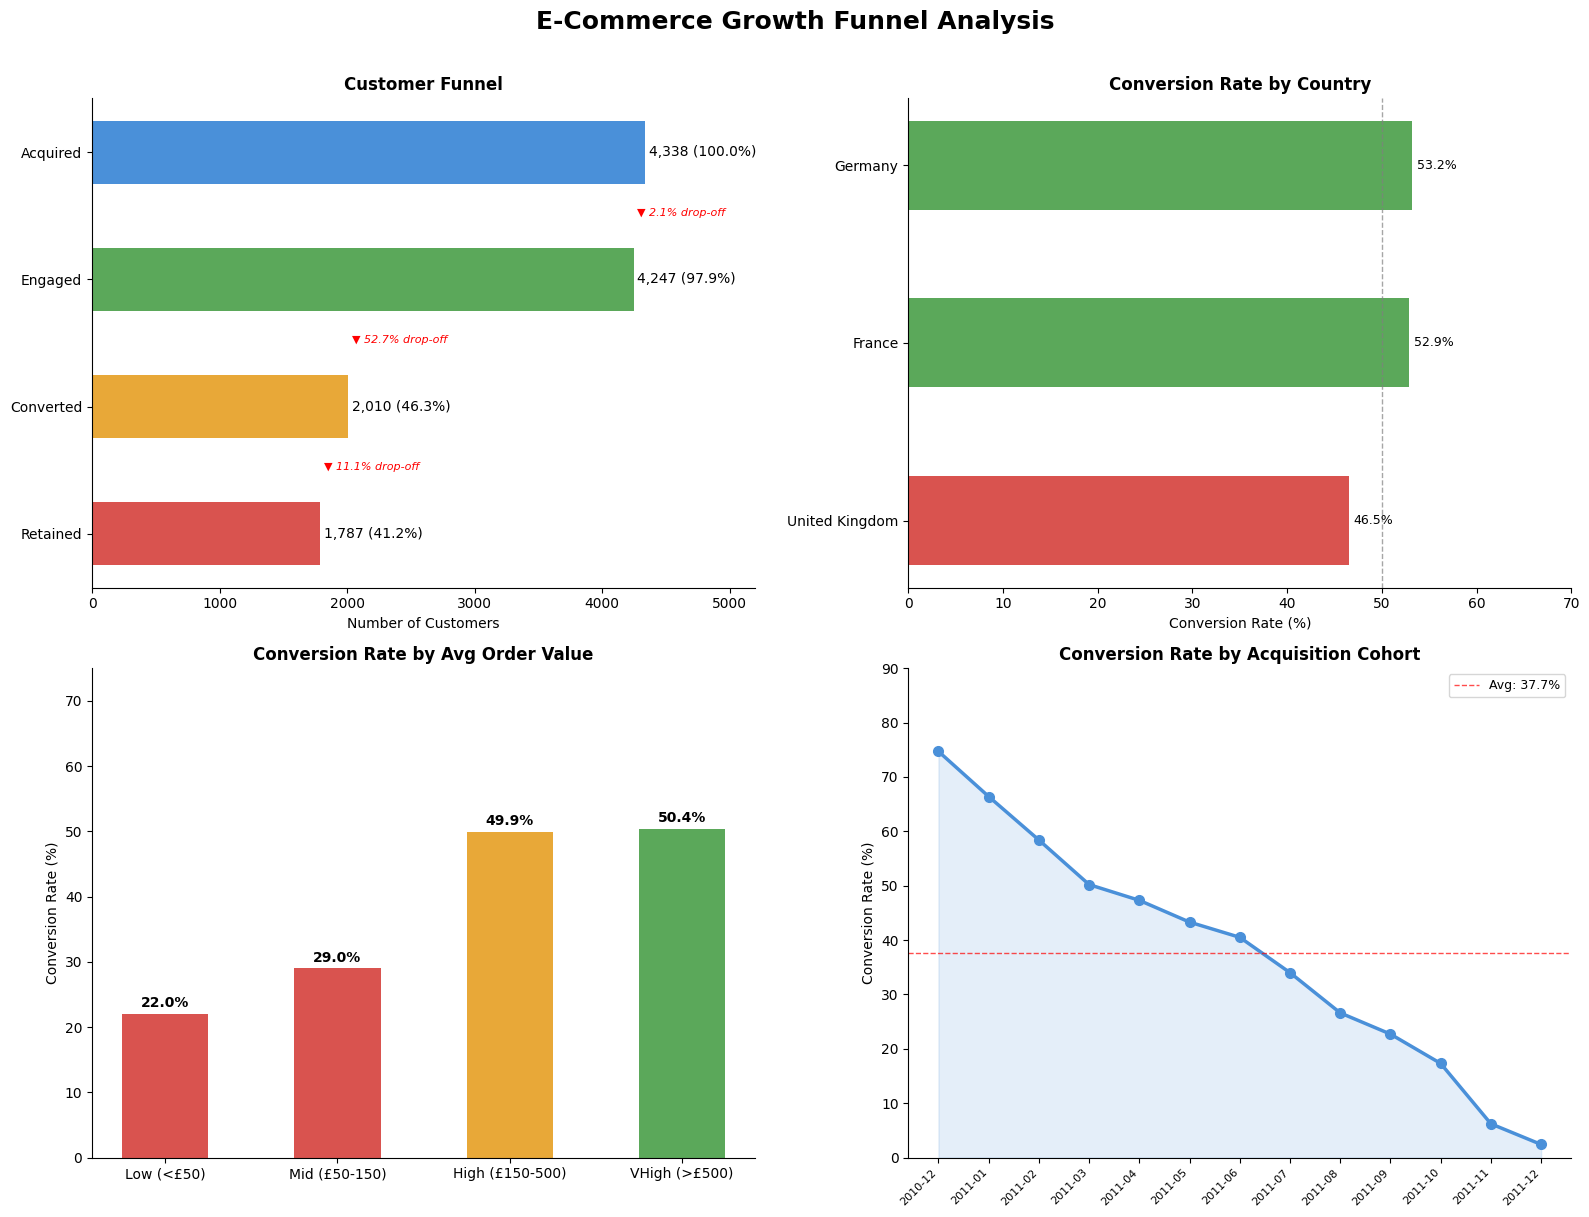

Chart saved as funnel_analysis.png


In [7]:
#Step 5: Visualizations
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('E-Commerce Growth Funnel Analysis', fontsize=18, fontweight='bold', y=1.01)

#Chart 1: Funnel
ax1 = axes[0, 0]
stages = funnel['Stage'].str.replace(r'^\d+\. ', '', regex=True)
customers = funnel['Customers']
colors = ['#4A90D9', '#5BA85A', '#E8A838', '#D9534F']

bars = ax1.barh(stages, customers, color=colors, height=0.5)
ax1.set_xlabel('Number of Customers')
ax1.set_title('Customer Funnel', fontweight='bold')
ax1.invert_yaxis()

for bar, val, pct in zip(bars, customers, funnel['Conversion %']):
    ax1.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
             f'{val:,} ({pct}%)', va='center', fontsize=10)
ax1.set_xlim(0, 5200)
ax1.spines[['top', 'right']].set_visible(False)

# Add drop-off annotations
for i in range(1, len(funnel)):
    drop = funnel['Drop-off %'].iloc[i]
    if drop > 0:
        ax1.annotate(f'▼ {drop}% drop-off',
                     xy=(customers.iloc[i] + 30, i - 0.5),
                     fontsize=8, color='red', style='italic')

#Chart 2: Conversion by Country
ax2 = axes[0, 1]
country_plot = country_funnel[['total', 'conversion_rate']].sort_values('conversion_rate', ascending=True)
bar_colors = ['#D9534F' if r < 50 else '#5BA85A' for r in country_plot['conversion_rate']]
bars2 = ax2.barh(country_plot.index, country_plot['conversion_rate'], color=bar_colors, height=0.5)
ax2.axvline(x=50, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax2.set_xlabel('Conversion Rate (%)')
ax2.set_title('Conversion Rate by Country', fontweight='bold')
ax2.spines[['top', 'right']].set_visible(False)

for bar, val in zip(bars2, country_plot['conversion_rate']):
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val}%', va='center', fontsize=9)
ax2.set_xlim(0, 70)

#Chart 3: Conversion by AOV Bucket
ax3 = axes[1, 0]
aov_plot = aov_funnel[['total', 'conversion_rate']].reset_index()
bar_colors3 = ['#D9534F' if r < 40 else '#E8A838' if r < 50 else '#5BA85A'
               for r in aov_plot['conversion_rate']]
bars3 = ax3.bar(aov_plot['aov_bucket'].astype(str), aov_plot['conversion_rate'],
                color=bar_colors3, width=0.5)
ax3.set_ylabel('Conversion Rate (%)')
ax3.set_title('Conversion Rate by Avg Order Value', fontweight='bold')
ax3.set_ylim(0, 75)
ax3.spines[['top', 'right']].set_visible(False)

for bar, val in zip(bars3, aov_plot['conversion_rate']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val}%', ha='center', fontsize=10, fontweight='bold')

#Chart 4: Cohort Conversion Over Time
ax4 = axes[1, 1]
cohort_plot = cohort_funnel[['total', 'conversion_rate']].reset_index()
cohort_plot['first_month'] = cohort_plot['first_month'].astype(str)

ax4.plot(cohort_plot['first_month'], cohort_plot['conversion_rate'],
         marker='o', color='#4A90D9', linewidth=2.5, markersize=7)
ax4.fill_between(range(len(cohort_plot)), cohort_plot['conversion_rate'],
                 alpha=0.15, color='#4A90D9')
ax4.set_xticks(range(len(cohort_plot)))
ax4.set_xticklabels(cohort_plot['first_month'], rotation=45, ha='right', fontsize=8)
ax4.set_ylabel('Conversion Rate (%)')
ax4.set_title('Conversion Rate by Acquisition Cohort', fontweight='bold')
ax4.axhline(y=cohort_plot['conversion_rate'].mean(), color='red',
            linestyle='--', linewidth=1, alpha=0.7, label=f"Avg: {cohort_plot['conversion_rate'].mean():.1f}%")
ax4.legend(fontsize=9)
ax4.spines[['top', 'right']].set_visible(False)
ax4.set_ylim(0, 90)

plt.tight_layout()
plt.savefig('funnel_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as funnel_analysis.png")

In [8]:
#Step 6: Insight & Recommendation Doc

doc = """
╔══════════════════════════════════════════════════════════════════════════════╗
║           E-COMMERCE GROWTH FUNNEL ANALYSIS — INSIGHT REPORT               ║
╚══════════════════════════════════════════════════════════════════════════════╝

ANALYST: [Your Name]
DATASET: Online Retail II (UCI ML Repository) | 397,885 transactions | 4,338 customers
PERIOD:  Dec 2010 – Dec 2011
TOOLS:   Python (Pandas, Matplotlib), Google Colab

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. FUNNEL OVERVIEW
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Acquired   →   Engaged   →   Converted   →   Retained
    4,338         4,247          2,010           1,787
   100.0%         97.9%          46.3%           41.2%

  Critical drop-off: Engaged → Converted  =  52.7% of engaged users never
  place 3+ orders. This is the primary growth leak.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
2. KEY FINDINGS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  FINDING 1 — New user cohorts are failing fast
  • Dec 2010 cohort converted at 74.7% (given enough time to mature)
  • Aug–Nov 2011 cohorts convert at only 17–34% — a 2x+ gap
  • Root cause hypothesis: insufficient onboarding or re-engagement for
    newly acquired customers; they buy once and disappear

  FINDING 2 — Low-value customers churn at alarming rates
  • Customers with avg order value <£50 convert at only 22%
  • Customers with AOV >£150 convert at ~50% — more than 2x higher
  • Root cause hypothesis: low-AOV customers may be one-time deal seekers,
    not genuine product fits; acquisition targeting may need tightening

  FINDING 3 — UK underperforms vs smaller markets
  • UK (87% of customers) converts at 46.5%
  • France and Germany convert at 52.9% and 53.2% respectively
  • Root cause hypothesis: UK customers may have more competitors/alternatives;
    or UK marketing drives lower-intent traffic

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
3. RECOMMENDATIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  REC 1 — Launch a 30-day new user re-engagement sequence  [HIGH PRIORITY]
  • Trigger email/push nudges at day 7, 14, 30 post first purchase
  • Goal: move cohort conversion from ~25% → 40% for new acquisitions
  • Projected impact: +600 converted customers on current acquisition volume

  REC 2 — Introduce an order incentive at the 2nd order milestone  [HIGH PRIORITY]
  • The Engaged → Converted cliff is at exactly the 3rd order threshold
  • A discount or loyalty reward triggered after order 2 could pull users
    across the conversion line
  • Benchmark: even a 5pp lift = ~210 additional converted customers

  REC 3 — Tighten UK acquisition targeting  [MEDIUM PRIORITY]
  • Audit UK paid channels for intent quality vs France/Germany
  • Shift budget toward higher-AOV customer acquisition signals
  • Goal: raise UK conversion rate from 46.5% → 50%+

"""

print(doc)


╔══════════════════════════════════════════════════════════════════════════════╗
║           E-COMMERCE GROWTH FUNNEL ANALYSIS — INSIGHT REPORT               ║
╚══════════════════════════════════════════════════════════════════════════════╝

ANALYST: [Your Name]
DATASET: Online Retail II (UCI ML Repository) | 397,885 transactions | 4,338 customers
PERIOD:  Dec 2010 – Dec 2011
TOOLS:   Python (Pandas, Matplotlib), Google Colab

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. FUNNEL OVERVIEW
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Acquired   →   Engaged   →   Converted   →   Retained
    4,338         4,247          2,010           1,787
   100.0%         97.9%          46.3%           41.2%

  Critical drop-off: Engaged → Converted  =  52.7% of engaged users never
  place 3+ orders. This is the primary growth leak.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
2. KEY FINDINGS
━━━━━━━